# LAB 3 : Associative Networks

Name : Sabyasachi Ghosal

Roll Number : 24PHDDI05

Reference Material :
1. **Chapter 4, page no. 90-110, Artificial Neural Network by B. Yegnanarayana**
2. https://in.mathworks.com/help/deeplearning/ug/linear-neural-networks.html


# **Problem 1** : Demonstrate the working principle of two layer auto-associative network. Observation to be demonstrated are:

1. Effect of orthonormal, orthogonal, linearly independent and linearly dependent input vectors.
2. Use all 3 learning rules (i.e. by computation, Widrow and Hebbian), to find the optimal weight and mention their pros. and cons.

Hints:

1. Generate data such that each input-output data points have different functional
relation.
2.  First do it using computation method for each set of data (i.e orthogonal, orthonormal, linearly independent and linearly dependent, then take the performance as reference, to implement using Widrow and Hebbian learning.

## Write down the Objectives, Hypothesis and Experimental description for the above problem



## Objective
To implement weights by Computation, weights by Widrow, and weights by Hebbian method for all type of inputs (i.e., Linearly independent, Linearly dependent, Orthonormal inputs). In pattern association, the task is to associate each input pattern with corresponding output pattern.

##  Hypothesis
For auto-association input and output pattern are similar (M = L). Feed forward neural network with linear units (linear output function) are used. The total number of patterns L that can be learnt is limited by the input dimension M i.e, L <= M. This is because there is a linear relation between input and output due to linear function.

## Experimental description
Given a set {($a_{l}, b_{l} $)} of L pattern pairs, the objective is to determine weights W of the linear associative network so as to minimize the error between desired output and actual output. The optimum weights are given by
- $W = BA^{-1}$ for linearly independent input vectors (full rank square matrix). Also, $W = BA^{+}$ for linearly independent (r = L < M)
- $W = BA^{+}$ for linearly dependent input vectors (r < L <= M)
- $W = BA^{T}$ for orthonormal input vectors (dot product = zero and magnitude = 1)


#### By Computation
In weights by computation, weights can be calculated as $W = BA^{-1}$. The minimum error can be calculated as $E_{min} = \frac{1}{L}||{B-WA}||^{2}$.
*   For linearly independent inputs, $A^{-1}$ exist so weights can be calculated as $W = BA^{-1}$ and $E_{min} = 0$.
*   For linearly dependent inputs, $W = BA^{-1}$ does not exist so weights are calculated as $W = BA^{+}$, where $A^{+}$ is pseudoinverse of $A$ and hence $E_{min} \neq 0$.
*   For Orthonormal inputs, $W = BA^{T}$ as $AA^{T} = A^{T}A = I$ and $E_{min} = 0$.


#### By Widrow's Learning rule
* In Widrow's method, we update the weights recursively to minimise the mean square error between true and predicted output $E_{min} = \frac{1}{L}||{B-B^{'}}||^{2}$.
* It is a special case of delta learning law where output function is assumed linear.
* Weights can be initialized to any random value as it is a supervised learning.
Approximated weight update equation is $W(l) = W(l−1) + η(b_{l} − W(l − 1)a_{l})a_{l}^{T}$.
η << 1 due to repeated use of training patterns (weights converge to final values by repeated use of input-output patterns)


#### By Hebbian Learning rule
In Hebbian rule, we update weights considering one pair of input and output at a time. Each pair of input and output are visited just once i.e., updates are done until each input output pair is visited.
The update equation is given as: $W(l) = W(l − 1) + b_{l}a_{l}^{T}$, here learning rate is kept $1$.
This can learn weights for orthonormal inputs only.

Verification:
*   $b = Wa_{k} = ∑_{l=1}^{L}b_{l}a^{T}_{l}a_{k} = b_{k}a^{T}_{k}a_{k}+∑_{l\neq k}b_{l}a_{l}^{T}a_{k}$
*   For orthonormal inputs $a^{T}_{l}a_{k}=1$ for $l=k$ ; and $a^{T}_{l}a_{k}=0$ for $l\neq k$. Hence correctly learns the weights.
*   If not orthogonal then $b_{k}^{'}=b_{k}+ϵ$. There will be an error $ϵ$. Hence, not able to predict exact output.

## Programming :
  Please write a program to demonstrate the same

In [107]:
## Write your code here to Generate the Data
## Important Parameters to generate data are : Number of Datapoints, Dimension of Data
import numpy as np
from scipy.stats import ortho_group
import matplotlib.pyplot as plt

In [108]:
X1 = np.array([[1,2,3],[2,1,3],[3,2,1]]).T
X2 = np.array([[1,2,3],[2,4,6],[3,2,1]]).T
X3 = ortho_group.rvs(dim=3)

b1 = (np.array([1,3,9])*X1)
b2 = (np.array([1,3,9])*X2)
b3 = (np.array([1,3,9])*X3)

print('\n ### Linearly independent inputs and outputs ### \n')
print('Inputs \n',X1,'\n Outputs \n',b1)

print('\n### Linearly dependent inputs and outputs ### \n')
print('Inputs \n',X2,'\n Outputs \n',b2)

print('\n### Orthonormal inputs and outputs ### \n')
print('Inputs \n',X3,'\n Outputs \n',b3)


 ### Linearly independent inputs and outputs ### 

Inputs 
 [[1 2 3]
 [2 1 2]
 [3 3 1]] 
 Outputs 
 [[ 1  6 27]
 [ 2  3 18]
 [ 3  9  9]]

### Linearly dependent inputs and outputs ### 

Inputs 
 [[1 2 3]
 [2 4 2]
 [3 6 1]] 
 Outputs 
 [[ 1  6 27]
 [ 2 12 18]
 [ 3 18  9]]

### Orthonormal inputs and outputs ### 

Inputs 
 [[ 0.45025486 -0.00475677 -0.89288741]
 [-0.15607915 -0.98500923 -0.07345823]
 [-0.87915292  0.17243604 -0.44424762]] 
 Outputs 
 [[ 0.45025486 -0.01427032 -8.03598673]
 [-0.15607915 -2.95502769 -0.66112411]
 [-0.87915292  0.51730812 -3.99822862]]


## Linear Independent Vectors (Inputs)
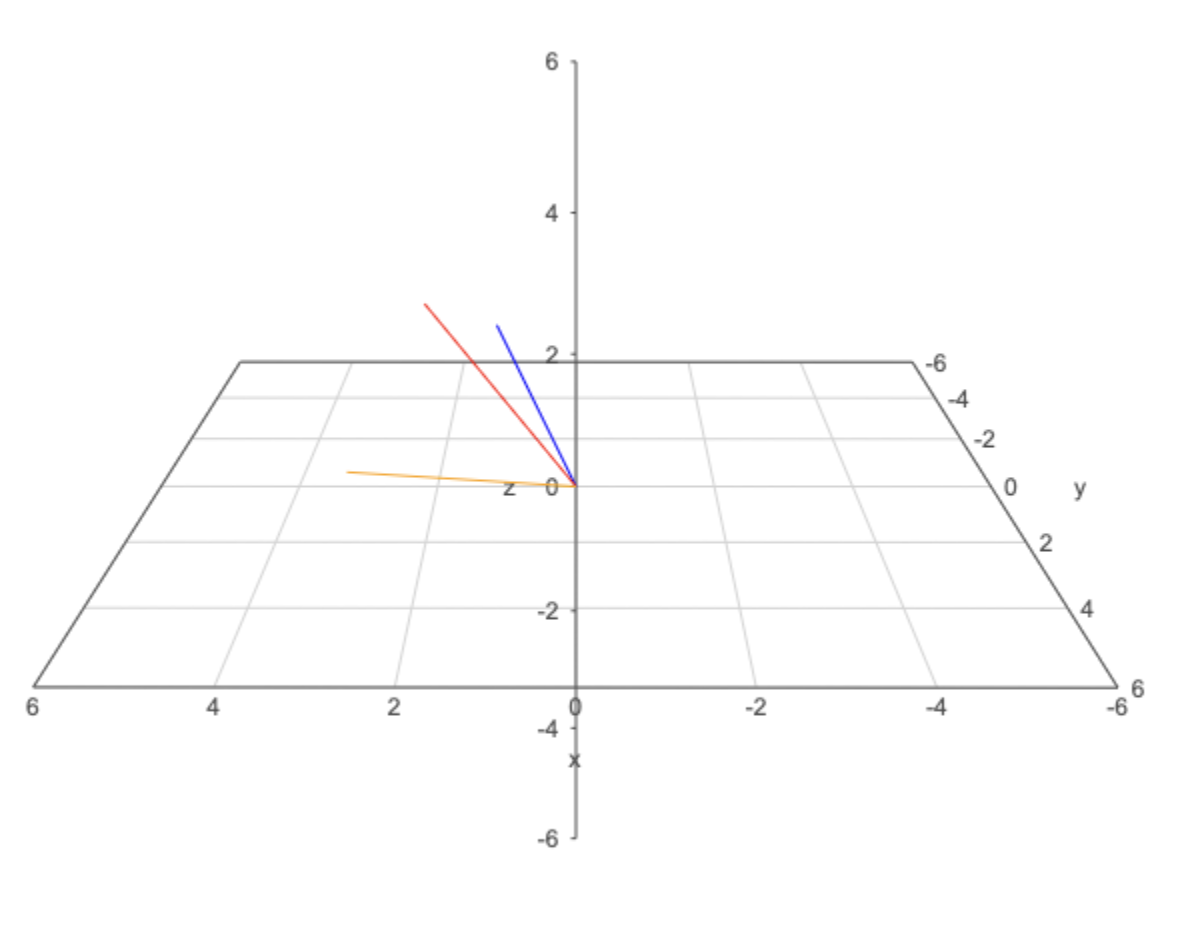
## Linear Dependent Vector (Inputs)
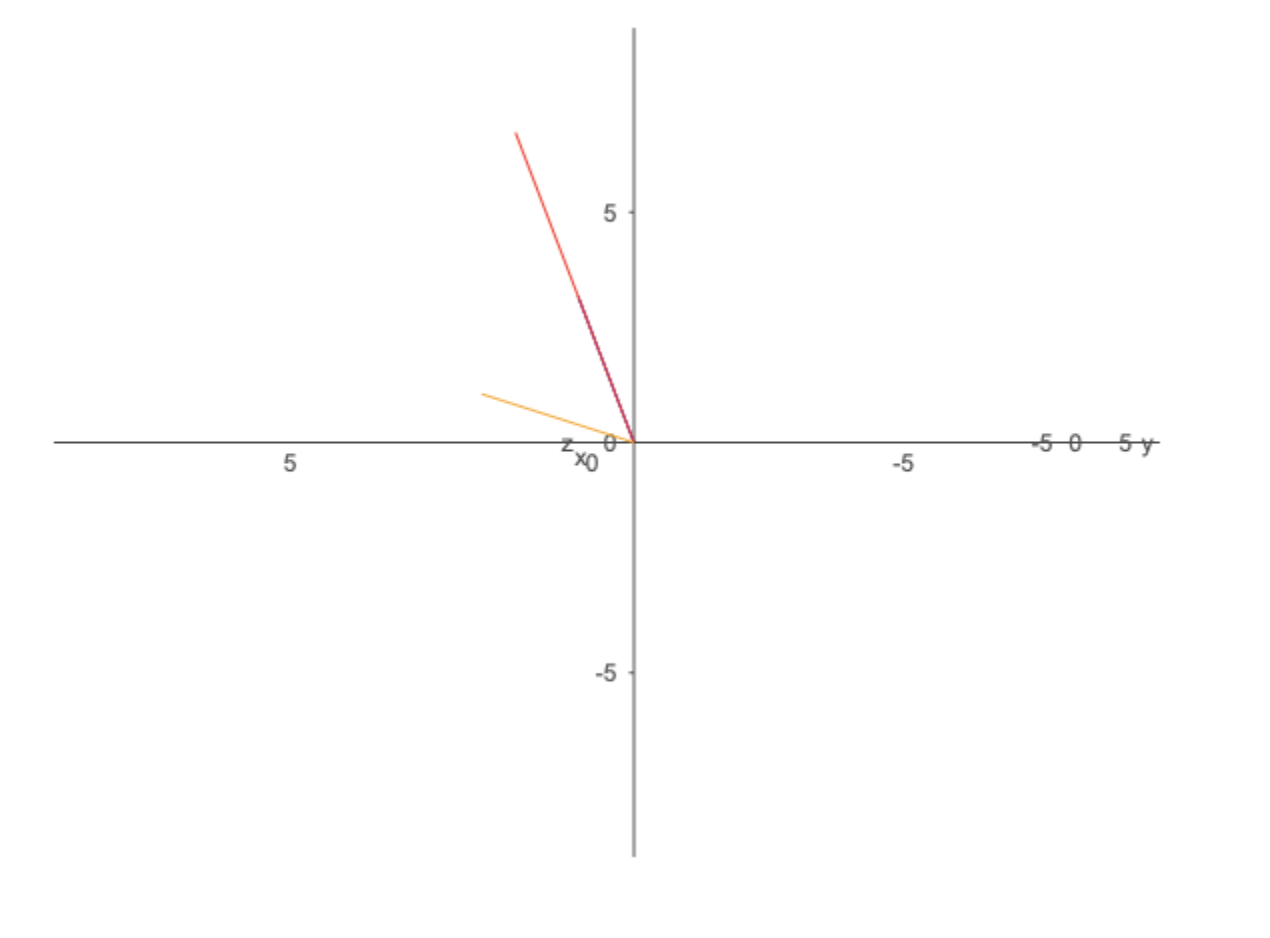
## Orthornomal Vectors (Inputs)
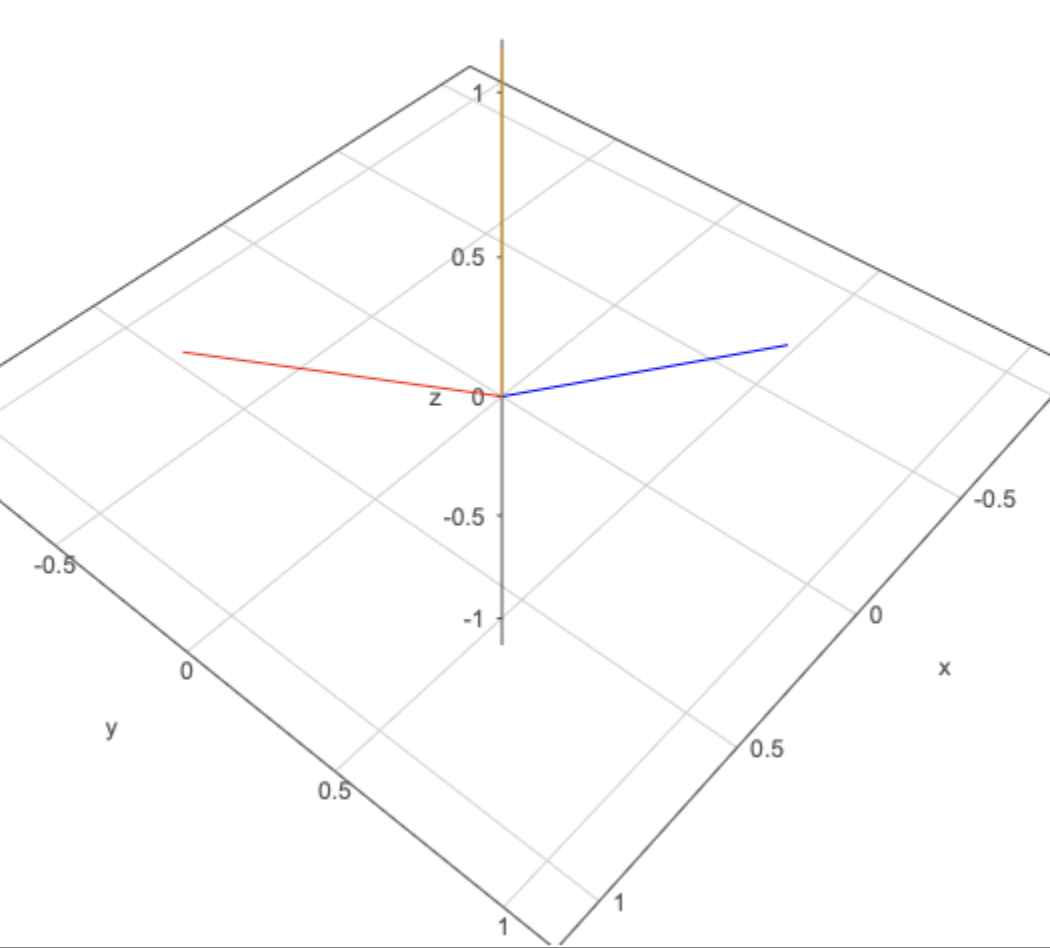

Generated using https://academo.org/demos/3d-vector-plotter/

In [109]:
def weights_by_computation(A,B):

    ## Write code here
    A_inverse = np.linalg.pinv(A)
    #print(A_inverse.shape)
    W = np.dot(B, A_inverse)
    B_pred = W @ A
    L = A.shape[1]
    error = np.square(np.linalg.norm(B - B_pred)) * (1 / L)
    return W, error

w1,e1 = weights_by_computation(X1,b1)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(w1,6))
print('\nError : ',np.round(e1,6))

w2,e2 = weights_by_computation(X2,b2)
print('\n### Weights and Error for Linearly dependent inputs ### \n')
print('weights : \n',np.round(w2,6))
print('\nError : ',np.round(e2,6))

w3,e3 = weights_by_computation(X3,b3)
print('\n### Weights and Error for Orthonormal inputs ### \n')
print('weights : \n',np.round(w3,6))
print('\nError : ',np.round(e3,6))


### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 8.333333  3.333333 -4.666667]
 [ 4.666667  3.666667 -3.333333]
 [ 4.       -2.        1.      ]]

Error :  0.0

### Weights and Error for Linearly dependent inputs ### 

weights : 
 [[ 8.566667  2.466667 -3.633333]
 [ 5.133333  1.933333 -1.266667]
 [ 1.7       1.4       1.1     ]]

Error :  14.933333

### Weights and Error for Orthonormal inputs ### 

weights : 
 [[ 7.378029  0.53409   3.171664]
 [ 0.53409   2.983655 -0.078633]
 [ 3.171664 -0.078633  2.638316]]

Error :  0.0


This experement concludes using the methods of computation, weights are learnt when the inputs are 
- linearly independent (perfectly), 
- linearly dependent (with some errors) 
- orthinormal (perfectly). 

[[ 8.33334136  3.33331806 -4.66666271]
 [ 4.66677028  3.6664696  -3.33328228]
 [ 3.99978237 -1.99958606  0.99989276]]
[np.float64(273.9036), np.float64(204.8038447733333), np.float64(169.15693862565863), np.float64(147.58987490330196), np.float64(132.2849746171743), np.float64(120.05766538499677), np.float64(109.58359731551987), np.float64(100.287666972857), np.float64(91.89869409623898), np.float64(84.27073313241141), np.float64(77.31120431379132), np.float64(70.95183346235936), np.float64(65.13676100988386), np.float64(59.8175491952089), np.float64(54.95097187440355), np.float64(50.49793689849598), np.float64(46.42287863656007), np.float64(42.693353913201896), np.float64(39.27973323183561), np.float64(36.154942789358685), np.float64(33.29423837631755), np.float64(30.67500259848746), np.float64(28.276561083097718), np.float64(26.080015103957113), np.float64(24.068088840282677), np.float64(22.224989861761788), np.float64(20.536281643174696), np.float64(18.988767050726906), np.float64(1

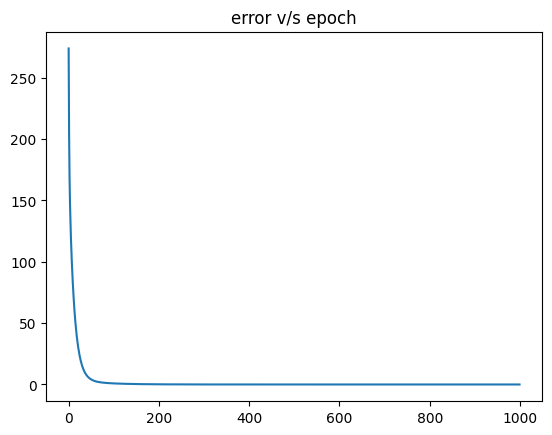

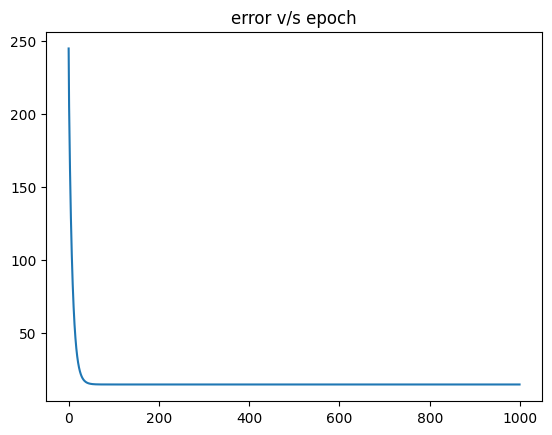

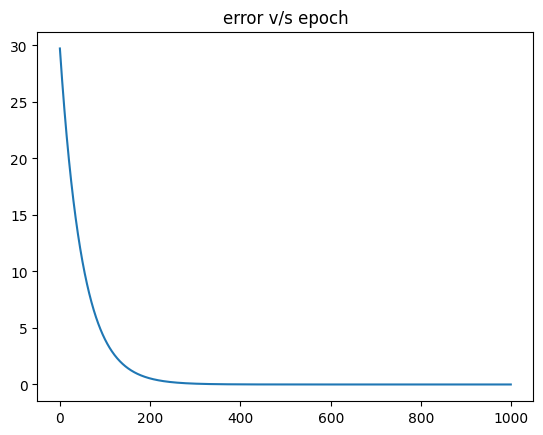

In [110]:
def weights_by_widrow(A,B,num_epochs,learning_rate):

    ## Write your code here
    w_l_1 = np.zeros((B.shape[0], A.shape[0]))
    #print(w_l_1.shape)
    errors = []
    w_l = w_l_1
    for epochs in range(num_epochs):
        w_l = w_l + learning_rate * ((B - w_l @ A) @ A.T)
        L = A.shape[1]
        B_ = w_l @ A  
        error =  1 / L * ((np.square(np.linalg.norm(B - B_))))
        errors.append(error)

    return w_l, errors


epoch = 1000
lr = 0.01
x = np.arange(epoch)
w1,e1 = weights_by_widrow(X1,b1,epoch,lr)
print(w1)
print(e1)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(w1,6))
print('\nError : ',np.round(e1[-1],6))
plt.figure()
plt.title('error v/s epoch')
plt.plot(x,e1)

w2,e2 = weights_by_widrow(X2,b2,epoch,lr)

print('\n### Weights and Error for Linearly dependent inputs ### \n')
print('weights : \n',np.round(w2,6))
print('\nError : ',np.round(e2[-1],6))
plt.figure()
plt.title('error v/s epoch')
plt.plot(x,e2)

w3,e3 = weights_by_widrow(X3,b3,epoch,lr)
print('\n### Weights and Error for Orthonormal inputs ### \n')
print('weights : \n',np.round(w3,6))
print('\nError : ',np.round(e3[-1],6))
plt.figure()
plt.title('error v/s epoch')
plt.plot(x,e3)

plt.show()


In [111]:
X1.shape

(3, 3)

(3, 3)

### Weights and Error for Linearly independent inputs ### 

weights : 
 [[94. 62. 48.]
 [62. 43. 33.]
 [48. 33. 45.]]

Error :  286938.0
(3, 3)

### Weights and Error for Linearly dependent inputs ### 

weights : 
 [[ 94.  80.  66.]
 [ 80.  88.  96.]
 [ 66.  96. 126.]]

Error :  1722332.0
(3, 3)

### Weights and Error for Orthonormal inputs ### 

weights : 
 [[ 7.378029  0.53409   3.171664]
 [ 0.53409   2.983655 -0.078633]
 [ 3.171664 -0.078633  2.638316]]

Error :  0.0


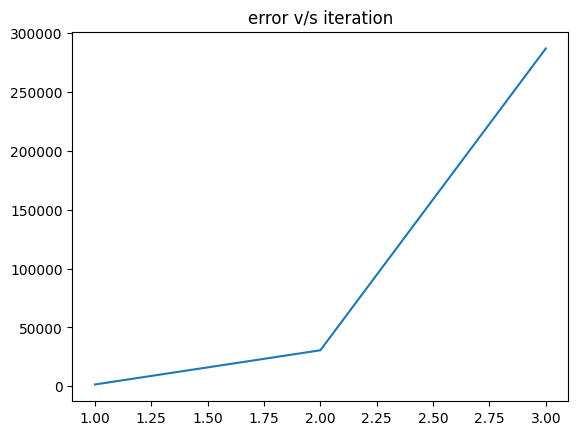

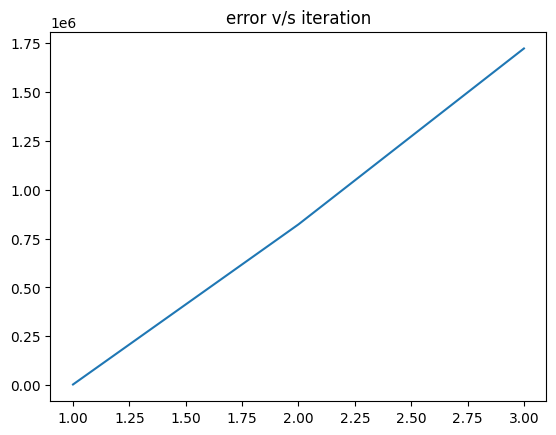

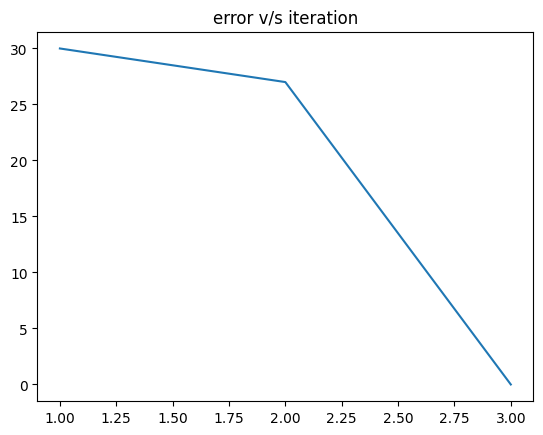

In [112]:
def weights_by_hebbian(A,B,num_epochs,learning_rate):

    ## Write your code here
    w_l_1 = np.zeros((B.shape[0], A.shape[0]))
    print(A.shape)
    errors = []
    w_l = w_l_1
    # taking vector in full, with 1 epoch
    for i in range(A.shape[1]):
        input_vector = np.matrix(A[:,i]).T
        output_vector = np.matrix(B[:,i]).T
        w_l = w_l + learning_rate * (output_vector@input_vector.T)
        L = A.shape[1]
        B_ = w_l @ A  
        error =  1 / L * ((np.square(np.linalg.norm(B - B_))))
        errors.append(error)

    return w_l, errors


epoch = 1000
lr = 1
x = np.arange(epoch)
w1,e1 = weights_by_hebbian(X1,b1,epoch,lr)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(w1,6))
print('\nError : ',np.round(e1[-1],6))
plt.figure()
plt.title('error v/s iteration')
plt.plot(np.arange(3)+1,e1)

w2,e2 = weights_by_hebbian(X2,b2,epoch,lr)
print('\n### Weights and Error for Linearly dependent inputs ### \n')
print('weights : \n',np.round(w2,6))
print('\nError : ',np.round(e2[-1],6))
plt.figure()
plt.title('error v/s iteration')
plt.plot(np.arange(3)+1,e2)

w3,e3 = weights_by_hebbian(X3,b3,epoch,lr)
print('\n### Weights and Error for Orthonormal inputs ### \n')
print('weights : \n',np.round(w3,6))
print('\nError : ',np.round(e3[-1],6))
plt.figure()
plt.plot(np.arange(3)+1,e3)
plt.title('error v/s iteration')
plt.show()

The Hebbs learning case the x axis is iterations
- Linearly Dependent : Error grows with iterations
- Linearly Independent - Error grows with iterations
- Orthonormal - Error decreases to 0 after 2nd itertions

## Inferences and Conclusion : State all the key observations and conclusion

In this experiemnt, the number of neurons (L) = Dimension of Input Vector (M). A *linear* neural network will only be able to learn when L = M.


### Weights by computation
- linearly independent - learns perfectly, 
- linearly dependent - learns with some errors, 
- orthinormal - learns perfectly. 


### Widrows Learning Law
- linearly independent - learns perfectly, 
- linearly dependent - with some errors, 
- orthinormal - learns perfectly. 

### Hebbs learning Law
- Linearly Dependent : Error grows with iterations, does not learn
- Linearly Independent - Error grows with iterations, does not learn
- Orthonormal - Error decreases to 0 after 2nd itertions, learns perfectly

# **Problem 2** : Demonstrate the working principle of two layer associative network performing hetero-association task (i.e each input output pair is related with different functional relations).

Observation to be demonstrated are:
1. Limitation of no. of patterns to input dimensionality.
2. Overcome the limitation by modifying the task to a pattern classification task.
3. Use computation and Widrow’s learning law to demonstrate the same.

Hints:

1. Generate data such that each input output data points have different functional
relation.
2. First do it using computation method , then take the performance as reference, to
implement using Widrow learning.
3. Modify the data and network element such that the network will overcome the
limitation of limitation of no. of data points with the input dimensionality, and
perform pattern classification task.

## Write down the Objectives, Hypothesis and Experimental description for the above problem



## Objective
To implement hetero-association (L != M) task with weights by Computation and weights by Widrow method. Here, L is the number of input-output patterns and M is the number of input units.

*   For $M>L$, the pattern association is learnt
*   For $M<L$, it is not able to learn weights

##  Hypothesis
- For hetero-association, number of patterns and number of neurons are different. The pattern association cannot be learnt when L > M because there is a linear relation between input and output due to linear function. Dependence of L on M can be removed completely by using non-linear processing units in the output layer. Thus, a two layer FFNN with non-linear units in the output layer can capture the association among the ({$a_{l}, b_{l}$}) pairs even when L > M.
- A set or group of input patterns assigned similar output patterns, then output patterns can be viewed as distinct classes or class labels.
-  ({$a_{l}, b_{l}$}) pairs can be considered as a training set for a pattern classification task.
- A two layer FFNN with nonlinear (hard-limiting) output function for units in output layer can be used to perform task of pattern classification.
- The neuron with hard-limiting output fn is termed as perceptron.
- Number of output units depends on the number of distinct classes.
- If activation value $x > \theta$, the input belongs to class A1, else A2.
- The equation $x = theta$ forms the equation of a hyperplane in M dimension.
- Perceptron learning law is used for weight updation.
- $w(m+1) = w(m) + ηa$, if a belongs to A1 and $w^{T}a ≤ 0$
- $w(m+1) = w(m) - ηa$, if a belongs to A2 and $w^{T}a > 0$

## Programming :
  Please write a program to demonstrate the same

In [113]:
## Write your code here to Generate the Data
## Important Parameters to generate data are : Number of Datapoints, Dimension of Data
M, L = 100,70
Input = np.random.rand(M,1)
r = 1 #matrix rank
while r < L:
    t = np.random.rand(M,1)
    if np.linalg.matrix_rank(np.hstack([Input,t])) > r:
        Input = np.hstack([Input,t])
        r+=1

data =  Input
N = 10
b = np.zeros((N,L))
for i in range(L):
    a = np.random.randint(10, size=1)
    b[0:N,i] = data[0:N,i]*a

print(data.shape)
print(b.shape)

(100, 70)
(10, 70)


The dimensional of input vector L = 70, M = 100
The dimensional of input vector L = 70, M = 10 

### For M>L
For this condition the inputs are linearly independent (i.e., input is full rank matrix) so weights can be learned by both weights by Computation and weights by Widrow method with error as $0$.
The error can be calculated as $E_{min}=\frac{1}{L}tr(B(I-A^{+}A)B^{T})$.
Hence we have $A^{+}A≃I$ for $M>L$ and $E_{min}=0.$

In [114]:
## You can use the same function defined above for computation method and widrow's learning law

# Weights by Computation
weights, errors = weights_by_computation(data,b)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(weights,6))
print('\nError : ',np.round(errors,6))


### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 2.576231e+00  5.801010e-01  4.988030e-01 -1.900273e+00  1.277180e-01
  -1.071988e+00 -1.847224e+00 -1.650121e+00  9.898140e-01 -5.430970e-01
  -5.201100e-02 -1.050607e+00  5.612200e-02 -1.113194e+00 -3.576290e-01
   4.176000e-01 -2.897390e-01  1.213930e+00 -1.598182e+00  1.484630e-01
  -3.281700e-02 -1.816470e-01  1.557859e+00 -5.225210e-01  8.549000e-01
   1.576766e+00  2.373670e-01  1.135430e-01  3.327560e-01  2.362740e-01
   1.847243e+00  8.166650e-01  1.608200e-02  2.010580e-01  8.761920e-01
  -7.308850e-01  7.856990e-01 -7.916240e-01 -1.429230e-01  9.237280e-01
   2.410800e-02  2.178040e-01 -1.106400e-01 -4.004250e-01  1.115606e+00
  -2.535803e+00  4.982030e-01  1.152233e+00 -1.465679e+00  2.662240e-01
  -6.451860e-01 -5.818020e-01 -1.160838e+00 -2.576790e-01  5.350810e-01
   9.256860e-01  9.905510e-01  3.274540e-01  2.874430e-01  2.737390e-01
   1.217762e+00  1.049134e+00  1.256380e-01 -1.498690e+00  1.43


### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 2.534999e+00  5.519580e-01  5.151890e-01 -1.888596e+00  1.699420e-01
  -1.024819e+00 -1.856438e+00 -1.635717e+00  9.690350e-01 -5.098700e-01
  -2.981300e-02 -1.020917e+00  4.636700e-02 -1.106279e+00 -3.631730e-01
   4.049010e-01 -2.840390e-01  1.171802e+00 -1.526776e+00  1.654810e-01
  -3.581500e-02 -1.665430e-01  1.525220e+00 -5.344710e-01  8.545310e-01
   1.572080e+00  2.250300e-01  1.053750e-01  3.312300e-01  2.367290e-01
   1.844002e+00  8.393260e-01  6.039000e-03  1.973200e-01  8.675710e-01
  -7.483480e-01  7.796200e-01 -7.894270e-01 -1.778520e-01  9.018260e-01
   1.766000e-02  2.017210e-01 -1.397820e-01 -4.052320e-01  1.095036e+00
  -2.497157e+00  4.825930e-01  1.148359e+00 -1.422606e+00  2.327460e-01
  -6.471570e-01 -5.941780e-01 -1.148537e+00 -2.466250e-01  5.103380e-01
   8.918160e-01  9.639300e-01  3.316610e-01  2.765340e-01  2.816580e-01
   1.246705e+00  1.052497e+00  1.365030e-01 -1.472820e+00  1.42

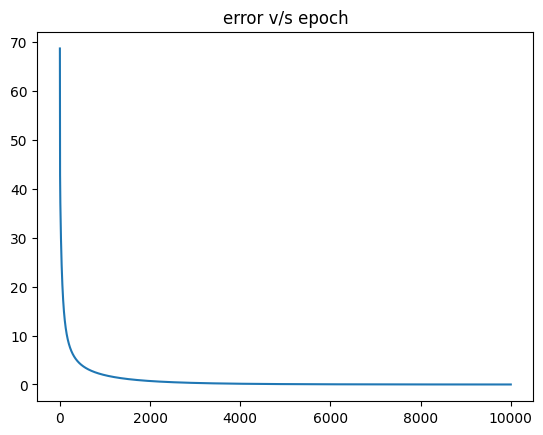

In [115]:
epoch = 10000
lr = 0.001
x = np.arange(epoch)
w1,e1 = weights_by_widrow(data,b,epoch,lr)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(w1,6))
print('\nError : ',np.round(e1[-1],6))
plt.figure()
plt.title('error v/s epoch')
plt.plot(x,e1)

Here the error is 0 by both Widrow & Computation

### For M<L
For this condition, the inputs are linearly dependent so both methods fails to learn the weights hence we get error here.
The error can be calculated as $E_{min}=\frac{1}{L}tr(B(I-A^{+}A)B^{T})$.
Hence we have $A^{+}A \neq I$ for $M<L$ and $E_{min}\neq 0.$


In [116]:
input = data[0:10,]
print(input.shape)
print(b.shape)


(10, 70)
(10, 70)


In [117]:
# Weights by Computation
weights, errors = weights_by_computation(input,b)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(weights,6))
print('\nError : ',np.round(errors,6))


### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 4.619258 -0.234864  0.405747 -1.492866 -0.082368  0.446066 -0.880411
   0.114854  0.635346  0.640389]
 [-0.835967  4.915765  0.207278 -0.981954 -0.521456 -0.46582  -0.818037
   0.216731  1.635362  1.195442]
 [ 0.359579  0.659493  4.437624 -0.688325 -1.056862 -0.64383  -0.755313
   0.173782  1.11586   0.905538]
 [-0.467258  0.640289  0.552064  3.73274  -0.53272  -0.728048 -0.891907
  -0.298199  1.012767  0.830317]
 [ 0.604034  0.700155 -0.077067 -1.524204  3.499319 -0.779998 -0.705658
   0.213965  1.13423   1.228475]
 [ 0.807108  0.979838  0.054385 -1.488143 -0.922643  3.739273 -1.024745
   0.238274  0.963001  1.110151]
 [-0.090279  1.0673    0.216961 -1.021277  0.009782 -0.260073  2.720724
  -0.060277  0.584807  0.841783]
 [ 0.297876  0.98438   0.171697 -1.703167 -0.331721 -0.118272 -1.010486
   4.48759   1.108516  0.544285]
 [-0.182024  1.758477  0.157872 -1.174391 -0.290748 -0.423516 -1.734456
   0.098099  5.


### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 4.619258 -0.234864  0.405747 -1.492866 -0.082368  0.446066 -0.880411
   0.114854  0.635346  0.640389]
 [-0.835967  4.915765  0.207278 -0.981954 -0.521456 -0.46582  -0.818037
   0.216731  1.635362  1.195442]
 [ 0.359579  0.659493  4.437624 -0.688325 -1.056862 -0.64383  -0.755313
   0.173782  1.11586   0.905538]
 [-0.467258  0.640289  0.552064  3.73274  -0.53272  -0.728048 -0.891907
  -0.298199  1.012767  0.830317]
 [ 0.604034  0.700155 -0.077067 -1.524204  3.499319 -0.779998 -0.705658
   0.213965  1.13423   1.228475]
 [ 0.807108  0.979838  0.054385 -1.488143 -0.922643  3.739273 -1.024745
   0.238274  0.963001  1.110151]
 [-0.090279  1.0673    0.216961 -1.021277  0.009782 -0.260073  2.720724
  -0.060277  0.584807  0.841783]
 [ 0.297876  0.98438   0.171697 -1.703167 -0.331721 -0.118272 -1.010486
   4.48759   1.108516  0.544285]
 [-0.182024  1.758477  0.157872 -1.174391 -0.290748 -0.423516 -1.734456
   0.098099  5.

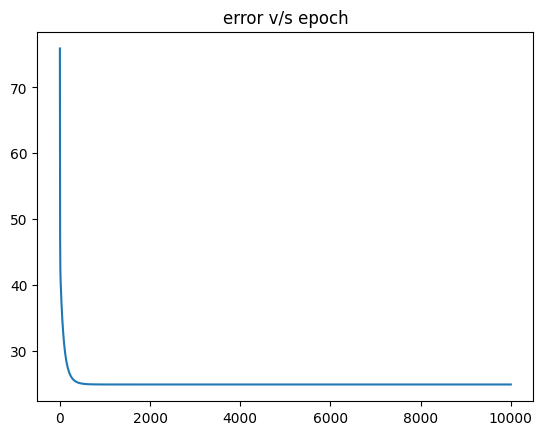

In [118]:
## You can use the same function defined above for computation method and widrow's learning law
# Write your code here
epoch = 10000
lr = 0.001
x = np.arange(epoch)
w1,e1 = weights_by_widrow(input,b,epoch,lr)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(w1,6))
print('\nError : ',np.round(e1[-1],6))
plt.figure()
plt.title('error v/s epoch')
plt.plot(x,e1)

## For Orthonormal vectors

Genarting data is done using the QR decomposition (np.linalg.qr). It is used to decompose Input into an orthogonal matrix (Q) and an upper triangular matrix  (R). Only Q is used as its columns are orthonormal vectors.

In [119]:
import numpy as np

M, L = 100, 70
Input = np.random.rand(M, L)

# Perform QR decomposition to get orthogonal vectors
Q, _ = np.linalg.qr(Input)

data = Q  # Now data contains orthonormal vectors as columns
N = 10
b = np.zeros((N, L))
for i in range(L):
    a = np.random.randint(10, size=1)
    b[0:N,i] = data[0:N,i]*a

print(data.shape)  # (M, L) where columns are orthonormal
print(b.shape)     # (N, L)


# Weights by Computation
weights, errors = weights_by_computation(input,b)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(weights,6))
print('\nError : ',np.round(errors,6))



(100, 70)
(10, 70)

### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 0.024886  0.057411 -0.14611  -0.228907  0.294036  0.049235 -0.122912
  -0.233266  0.018765  0.12394 ]
 [ 0.191137 -0.146904  0.042333 -0.004368  0.222656  0.274472 -0.165613
  -0.11296  -0.505424  0.100016]
 [ 0.155661  0.204627  0.03914   0.12205  -0.240524  0.080818 -0.399213
   0.338931  0.072084 -0.356641]
 [ 0.10954   0.099642  0.029472 -0.154848 -0.113986 -0.248782  0.392728
   0.288736 -0.55045   0.345295]
 [ 0.351865  0.135577 -0.105736  0.07582   0.02031  -0.251129  0.064851
  -0.05271  -0.295121  0.116475]
 [-0.292878  0.069946 -0.060477  0.099907  0.492746 -0.126761 -0.049979
  -0.422348  0.07831  -0.025977]
 [ 0.416701  0.070994 -0.009276 -0.397758 -0.15207   0.281118  0.225741
  -0.019921 -0.499809  0.158777]
 [-0.492507 -0.156968  0.003272  0.158014  0.272293  0.231035  0.008574
  -0.323419 -0.374168  0.548656]
 [-0.25233  -0.050077  0.195027 -0.420715 -0.104949  0.295335  0.189


### Weights and Error for Linearly independent inputs ### 

weights : 
 [[ 0.024886  0.057411 -0.14611  -0.228907  0.294036  0.049235 -0.122912
  -0.233266  0.018765  0.12394 ]
 [ 0.191137 -0.146904  0.042333 -0.004368  0.222656  0.274472 -0.165613
  -0.11296  -0.505424  0.100016]
 [ 0.155661  0.204627  0.03914   0.12205  -0.240524  0.080818 -0.399213
   0.338931  0.072084 -0.356641]
 [ 0.10954   0.099642  0.029472 -0.154848 -0.113986 -0.248782  0.392728
   0.288736 -0.55045   0.345295]
 [ 0.351865  0.135577 -0.105736  0.07582   0.02031  -0.251129  0.064851
  -0.05271  -0.295121  0.116475]
 [-0.292878  0.069946 -0.060477  0.099907  0.492746 -0.126761 -0.049979
  -0.422348  0.07831  -0.025977]
 [ 0.416701  0.070994 -0.009276 -0.397758 -0.15207   0.281118  0.225741
  -0.019921 -0.499809  0.158777]
 [-0.492507 -0.156968  0.003272  0.158014  0.272293  0.231035  0.008574
  -0.323419 -0.374168  0.548656]
 [-0.25233  -0.050077  0.195027 -0.420715 -0.104949  0.295335  0.189923
   0.33088  -0.

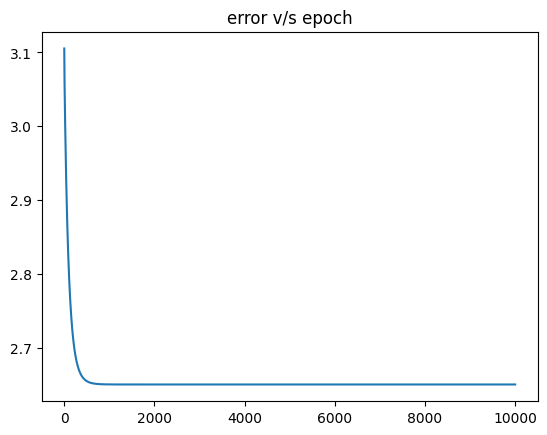

In [120]:
epoch = 10000
lr = 0.001
x = np.arange(epoch)
w1,e1 = weights_by_widrow(input,b,epoch,lr)
print('\n### Weights and Error for Linearly independent inputs ### \n')
print('weights : \n',np.round(w1,6))
print('\nError : ',np.round(e1[-1],6))
plt.figure()
plt.title('error v/s epoch')
plt.plot(x,e1)

In [121]:
w3,e3 = weights_by_hebbian(input,b,epoch,lr)
print('\n### Weights and Error for Orthonormal inputs ### \n')
print('weights : \n',np.round(w3,6))
print('\nError : ',np.round(e3[-1],6))


(10, 70)

### Weights and Error for Orthonormal inputs ### 

weights : 
 [[-1.881e-03 -2.022e-03 -2.677e-03 -3.606e-03 -1.191e-03 -2.210e-03
  -2.774e-03 -2.979e-03 -1.943e-03 -1.594e-03]
 [ 2.670e-04 -2.170e-03 -3.220e-04 -1.157e-03 -9.900e-05 -5.700e-04
  -2.671e-03 -1.706e-03 -4.829e-03 -1.502e-03]
 [-2.510e-04  1.790e-04 -9.980e-04 -1.320e-04 -1.912e-03 -9.290e-04
  -3.228e-03  8.190e-04 -1.481e-03 -2.963e-03]
 [ 3.110e-03  3.533e-03  2.850e-03  2.235e-03  2.890e-03  2.068e-03
   4.333e-03  4.206e-03 -1.840e-04  4.359e-03]
 [ 3.001e-03  1.253e-03  3.720e-04  1.553e-03  1.358e-03 -8.250e-04
   7.210e-04  3.580e-04 -1.349e-03  5.760e-04]
 [-2.752e-03 -1.856e-03 -1.784e-03 -1.971e-03 -3.850e-04 -2.984e-03
  -2.407e-03 -4.141e-03 -1.636e-03 -2.559e-03]
 [ 1.594e-03  4.990e-04  2.120e-04 -1.728e-03 -7.050e-04  1.188e-03
   9.440e-04 -2.550e-04 -3.036e-03  5.810e-04]
 [-2.495e-03 -5.640e-04  7.450e-04  9.500e-05  4.180e-04  1.521e-03
  -1.900e-05 -1.392e-03 -1.556e-03  2.836e-03]
 [-5.04

## Inferences and Conclusion : State all the key observations and conclusion

Here M is the number of input vectors and L is the number of neurons. Here Linear Neural Network is considered and Activation function is also Linear (LMS) for Widrows Learning Law. Hebbian it is linear because it is column wise one iteration. 

### When M >= L,
#### Weights by computation
- linearly independent - learns perfectly, 
- linearly dependent - learns with some errors, 
- orthinormal - learns perfectly. 


#### Widrows Learning Law
- linearly independent - learns perfectly, 
- linearly dependent - with some errors, 
- orthonormal - learns perfectly. 

#### Hebbs learning Law
- Linearly Dependent : Does not learn, Error grows with iterations, 
- Linearly Independent - Does not learn, Error grows with iterations, 
- Orthonormal - Learns perfectly, Error decreases to 0 after 2nd itertions, 


### When M < L

#### Computation method 
- Linearly Independent - Does not learn (Error is not 0)
- Orthonromal - Does not learn (Error is not 0)
#### Widrow Learning 
- Linearly independent - Does not learn  (Error is not 0)
- Orthonromal - Does not learn (Error is not 0)

#### Hebian Learning Law
- Orthonormal - Does not learn (Error is not 0)
